# install Libraries

In [1]:
!pip install tensorflow matplotlib numpy pandas scikit-learn pillow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 1.7 MB/s eta 0:03:26
   ---------------------------------------- 0.8/351.2 MB 1.4 MB/s eta 0:04:03
   ---------------------------------------- 1.0/351.2 MB 1.3 MB/s eta 0:04:24
   ---------------------------------------- 1.0/351.2 MB 1.3 MB/s eta 0:04:24
   ---------------------------------------- 1.0/351.2 MB 1.3 MB/s eta 0:04:24
   ---------------------------------------- 1.6/351.2 MB 1.1 MB/s eta 0:05:29
   ---------------------------------------- 1.8/351.2 MB 1.1 MB/s eta 0:05:24
   ---------------------------------------- 2.4/351.2 MB 1.2 MB/s eta 0:04:52
   ---------------------------------------- 2.6/351.2 MB 1.2 MB/s eta 0:04:52
   ---------------------------------------- 2.9/351.2 MB 1.2 MB/s eta 0:04:53
   ----


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [6]:
dataset_path = "C:/Users/Administrator/image_classification/PetImages"

In [7]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [8]:
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 19968 images belonging to 2 classes.


In [9]:
val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 4991 images belonging to 2 classes.


In [10]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step


In [11]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
496/624 ━━━━━━━━━━━━━━━━━━━━ 2:10 1s/step - accuracy: 0.9728 - loss: 0.0733

C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


624/624 ━━━━━━━━━━━━━━━━━━━━ 1300s 2s/step - accuracy: 0.9739 - loss: 0.0708 - val_accuracy: 0.9814 - val_loss: 0.0447
Epoch 2/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 731s 1s/step - accuracy: 0.9818 - loss: 0.0480 - val_accuracy: 0.9856 - val_loss: 0.0403
Epoch 3/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 728s 1s/step - accuracy: 0.9828 - loss: 0.0434 - val_accuracy: 0.9794 - val_loss: 0.0539
Epoch 4/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 730s 1s/step - accuracy: 0.9850 - loss: 0.0392 - val_accuracy: 0.9812 - val_loss: 0.0482
Epoch 5/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 732s 1s/step - accuracy: 0.9850 - loss: 0.0375 - val_accuracy: 0.9842 - val_loss: 0.0414


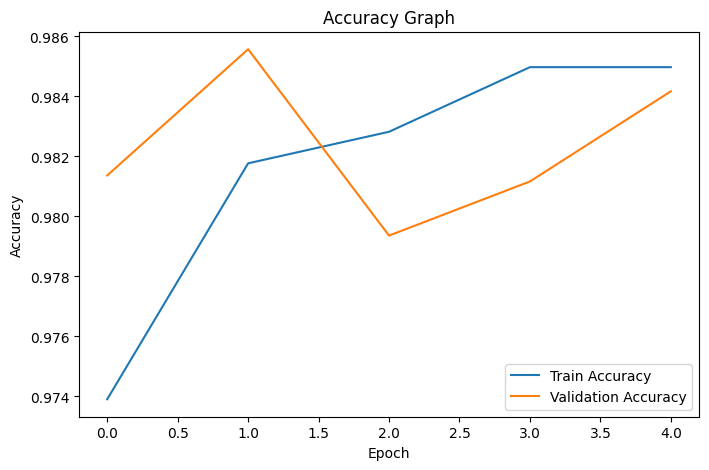

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Graph')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("accuracy_graph.png")
plt.show()

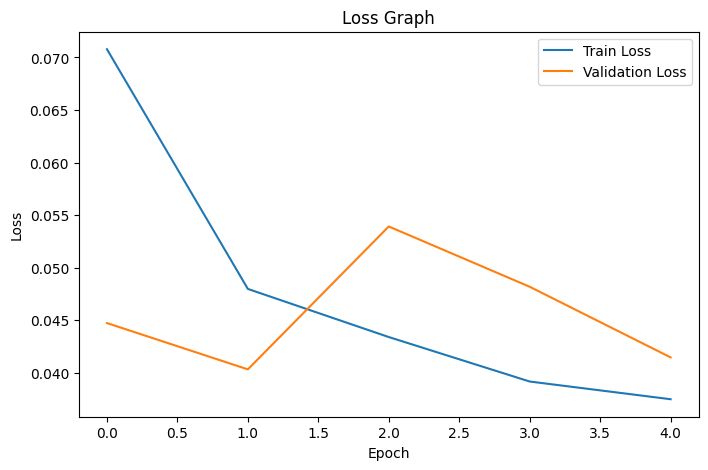

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Graph')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig("loss_graph.png")
plt.show()

In [16]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

156/156 ━━━━━━━━━━━━━━━━━━━━ 146s 938ms/step - accuracy: 0.9856 - loss: 0.0399
Validation Accuracy: 0.9855740070343018
Validation Loss: 0.03985859826207161


In [17]:
model.save("cats_dogs_mobilenetv2.h5")

In [19]:
from tensorflow.keras.preprocessing import image

img_path = "test.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Dog
